In [ ]:
from itertools import product

import numpy as np
import pandas as pd
import torch
from torch import nn, optim, cuda
from torch.utils.data import Dataset, DataLoader, TensorDataset, random_split
from torchvision.datasets import MNIST, FashionMNIST, CIFAR10, OxfordIIITPet, CIFAR100
from torchvision.models import resnet18, ResNet18_Weights
from torchvision.transforms import (
    InterpolationMode,
    Compose,
    Resize,
    ToTensor,
    PILToTensor,
    Normalize,
)
from torchvision.models.feature_extraction import create_feature_extractor
from PIL import Image
from tqdm import tqdm, trange
from matplotlib import pyplot as plt
import sklearn
from sklearn.model_selection import train_test_split

data_dir = "~/DataScience/datasets/"

In [ ]:
device = "cuda" if cuda.is_available() else "cpu"
print("Using device:", device)

## Solution 2

In [ ]:
batch_size = 512
transform = Compose(
    [
        ToTensor(),  # this does Min-Max normalization: maps to [0,1]
        Normalize(
            mean=[0.4914, 0.4822, 0.4465], std=[0.2470, 0.2435, 0.2616]
        ),  # mean, std of CIFAR10 3 features. Source: https://stackoverflow.com/a/69750247/12947681
    ]
)
train_ds = CIFAR10(data_dir, download=True, train=True, transform=transform)
valid_ds = CIFAR10(data_dir, download=True, train=False, transform=transform)
train_loader = DataLoader(train_ds, batch_size=batch_size)
valid_loader = DataLoader(valid_ds, batch_size=batch_size)

100%|██████████| 170M/170M [00:05<00:00, 29.9MB/s] 


In [ ]:
def train(model, output_layer, epochs: int):
    model = model.to(device)
    loss_fn = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
    train_losses = []
    valid_accuracies = []
    output_gradient_norms = []
    for epoch in range(epochs):
        # train
        model.train()
        epoch_train_loss = 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            logits = model(images)
            loss = loss_fn(logits, labels)
            epoch_train_loss += loss.item()
            loss.backward()
            optimizer.step()
        train_losses.append(
            epoch_train_loss / len(train_loader)
        )  # divide by no. of batches to get average loss over all batches

        # validate
        model.eval()
        with torch.no_grad():
            correct_predicted = sum(
                (
                    torch.argmax(model(images.to(device)), dim=1) == labels.to(device)
                ).sum()
                for images, labels in valid_loader
            )
            valid_accuracies.append(
                correct_predicted.item() / len(train_loader)
            )  # divide by no. of batches to average

        # gradient norm of output layer
        output_gradient_norms.append(output_layer.weight.grad.norm().item())

        print(
            f"{epoch=}: Train Loss={train_losses[epoch]}, Validation Accuracy={valid_accuracies[epoch]}, Gradient Norm={output_gradient_norms[epoch]}"
        )

    return train_losses, valid_accuracies, output_gradient_norms

In [ ]:
# Resnet Transfer Learn
resnet10_model = resnet18(weights=ResNet18_Weights)  # pretrained (on ImageNet dataset)
resnet10_model.fc = nn.Linear(
    in_features=resnet10_model.fc.in_features, out_features=10
)

# train after freezing all layers except fc head
for param in resnet10_model.parameters():
    param.requires_grad = False
for param in resnet10_model.fc.parameters():
    param.requires_grad = True
losses1, accuracies1, grad_norms1 = train(resnet10_model, resnet10_model.fc, epochs=5)
print("\n\nTRAINING DONE FOR 5 EPOCHS\n\n")

# fine tune after unfreezing last residual block
for param in resnet10_model.layer4[1].parameters():
    param.requires_grad = True
losses2, accuracies2, grad_norms2 = train(resnet10_model, resnet10_model.fc, epochs=10)
print("FINE TUNING DONE FOR 10 epochs")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 205MB/s]


epoch=0: Train Loss=2.1502023521734746, Validation Accuracy=34.33673469387755, Gradient Norm=1.9297494888305664
epoch=1: Train Loss=1.8324449050183198, Validation Accuracy=39.826530612244895, Gradient Norm=1.848815679550171


In [ ]:
def cnn_block(in_channels: int, out_channels: int):
    return [
        nn.Conv2d(in_channels, out_channels, kernel_size=(3, 3)),
        nn.ReLU(),
        nn.Conv2d(out_channels, out_channels, kernel_size=(3, 3)),
        nn.ReLU(),
    ]


cnn = nn.Sequential(
    *cnn_block(3, 64),
    nn.MaxPool2d(kernel_size=(2, 2)),
    *cnn_block(64, 128),
    nn.MaxPool2d(kernel_size=(2, 2)),
    nn.Flatten(),
    # fully-connected head
    nn.Linear(3200, 512),
    nn.ReLU(),
    nn.Dropout(0.9),
    nn.Linear(512, 10),
)
cnn_losses, cnn_accuracies, cnn_grad_norms = train(cnn, cnn[-1], epochs=15)

epoch=0: Train Loss=2.3022012369973317, Validation Accuracy=0.02255999855697155, Gradient Norm=0.06187872216105461
epoch=1: Train Loss=2.300200953775523, Validation Accuracy=0.023439999669790268, Gradient Norm=0.06834111362695694
epoch=2: Train Loss=2.297164255258988, Validation Accuracy=0.02719999849796295, Gradient Norm=0.0797574520111084
epoch=3: Train Loss=2.2912300362878915, Validation Accuracy=0.030339999124407768, Gradient Norm=0.11666705459356308
epoch=4: Train Loss=2.276345201901027, Validation Accuracy=0.03247999772429466, Gradient Norm=0.2143169641494751
epoch=5: Train Loss=2.2360812693226095, Validation Accuracy=0.03689999878406525, Gradient Norm=0.4420575201511383
epoch=6: Train Loss=2.180072047272507, Validation Accuracy=0.0423399992287159, Gradient Norm=0.5806629657745361
epoch=7: Train Loss=2.1248672154484964, Validation Accuracy=0.045479997992515564, Gradient Norm=0.6690211296081543
epoch=8: Train Loss=2.0809393172361412, Validation Accuracy=0.05009999871253967, Gradie

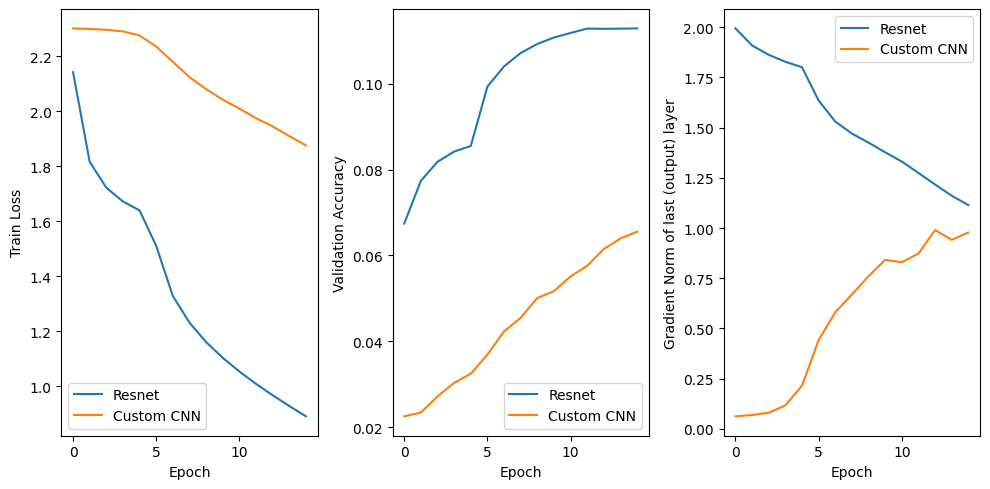

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(10, 5))
axes[0].plot(losses1 + losses2, label="Resnet")
axes[0].plot(cnn_losses, label="Custom CNN")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Train Loss")
axes[0].legend()

axes[1].plot(accuracies1 + accuracies2, label="Resnet")
axes[1].plot(cnn_accuracies, label="Custom CNN")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Validation Accuracy")
axes[1].legend()

axes[2].plot(grad_norms1 + grad_norms2, label="Resnet")
axes[2].plot(cnn_grad_norms, label="Custom CNN")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Gradient Norm of last (output) layer")
axes[2].legend()
fig.tight_layout()

Comparision
* Convergence Speed: Loss converges towards 0 much faster in fine-tuned Resnet (using pre-trained weights) than in custom CNN.
* In fine-tuned Resnet, gradient norm gradually decreases. It starts out strong due to *BatchNorm* layers and skip connections.
  But in custom CNN, gradient norm starts off very low, suggesting it suffers from **Vanishing Gradients** problem in earlier epochs.
* Final validataion accuracy is better in case of fine-tuned Resnet (11.28%) than in CNN (6.5%) .

Pre-trained weights act as a form of Regularization as they constrain search space. Model starts off with weights that already know how to identify edges, textures, etc. so it doesn't have to search the whole space from scratch.

Deeper residual networks learn better as they can deal with **Identity Mapping** due to skip connections. A skip connection is $y = F(x) + x$ - if a layer is redundant, model can learn weights to set $F(x)$ to 0 so that input $x$ can flow on unimpeded.

## Solution 4

In [ ]:
class OxfordPetsSegmentation(Dataset):
    def __init__(self, root=".", split="train", image_size=128):
        self.dataset = OxfordIIITPet(
            root=root, download=True, target_types="segmentation"
        )
        self.images = self.dataset._images
        self.masks = self.dataset._segs
        total = len(self.images)
        if split == "train":
            self.images = self.images[: int(0.8 * total)]
            self.masks = self.masks[: int(0.8 * total)]
        else:
            self.images = self.images[int(0.8 * total) :]
            self.masks = self.masks[int(0.8 * total) :]

        self.img_transform = Compose([Resize((image_size, image_size)), ToTensor()])
        self.mask_transform = Compose(
            [
                Resize(
                    (image_size, image_size), interpolation=InterpolationMode.NEAREST
                ),
                PILToTensor(),
            ]
        )

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = Image.open(self.images[idx]).convert("RGB")
        mask = Image.open(self.masks[idx])
        img = self.img_transform(img)
        mask = self.mask_transform(mask).squeeze(0) - 1
        return img, mask.long()


# TODO

## Solution 7

In [ ]:
dataset = sklearn.datasets.fetch_california_housing(as_frame=True)
features_df, prices = dataset["data"], dataset["target"]
Xtrain, Xvalid, ytrain, yvalid = train_test_split(
    features_df, prices, train_size=0.8, random_state=42
)
Xtrain.shape, ytrain.shape, Xvalid.shape, yvalid.shape

((16512, 8), (16512,), (4128, 8), (4128,))

In [ ]:
Xmax = Xtrain.max()
Xmin = Xtrain.min()
Xmean = Xtrain.mean()
Xstd = Xtrain.std()
Xtrain_norm = (Xtrain - Xmin) / (Xmax - Xmin)
Xtrain_standard = (Xtrain - Xmean) / Xstd
Xvalid_norm = (Xvalid - Xmin) / (Xmax - Xmin)
Xvalid_standard = (Xvalid - Xmean) / Xstd

In [ ]:
input_features = Xtrain.shape[1]
loss_fn = nn.MSELoss()
epochs = 100

In [ ]:
def train(Xtrain, ytrain, Xvalid, yvalid):
    Xtrain, ytrain, Xvalid, yvalid = [
        torch.from_numpy(df.to_numpy()).float()
        for df in (Xtrain, ytrain, Xvalid, yvalid)
    ]
    train_ds = TensorDataset(Xtrain, ytrain)
    valid_ds = TensorDataset(Xvalid, yvalid)
    train_loader = DataLoader(train_ds, batch_size=512)
    valid_loader = DataLoader(valid_ds, batch_size=512)

    model = nn.Sequential(
        nn.Linear(input_features, 64),
        nn.ReLU(),
        nn.Linear(64, 64),
        nn.ReLU(),
        nn.Linear(64, 32),
        nn.ReLU(),
        nn.Linear(32, 16),
        nn.ReLU(),
        nn.Linear(16, 1),
    )
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    valid_losses = []

    for epoch in range(epochs):
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            outputs = model(x)
            train_loss = loss_fn(outputs, y)
            train_loss.backward()
            optimizer.step()

        with torch.no_grad():
            total_valid_loss = sum(
                loss_fn(model(x.to(device)), y.to(device)).item()
                for x, y in valid_loader
            )
            valid_losses.append(total_valid_loss / len(valid_loader))

        print(f"{epoch=}: Validataion Loss: {valid_losses[epoch]}")

    return valid_losses


In [ ]:
raw_valid_losses = train(Xtrain, ytrain, Xvalid, yvalid)

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([512])) that is different to the input size (torch.Size([512, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([128])) that is different to the input size (torch.Size([128, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([32])) that is different to the input size (torch.Size([32, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(in

epoch=0: Validataion Loss: 1.5130923456615872
epoch=1: Validataion Loss: 1.3733036518096924
epoch=2: Validataion Loss: 1.3713458246654935
epoch=3: Validataion Loss: 1.411887288093567
epoch=4: Validataion Loss: 1.4332859383689032
epoch=5: Validataion Loss: 1.4155699014663696
epoch=6: Validataion Loss: 1.3922193712658353
epoch=7: Validataion Loss: 1.3828666077719793
epoch=8: Validataion Loss: 1.3857224252488878
epoch=9: Validataion Loss: 1.3843288951449924
epoch=10: Validataion Loss: 1.3794267839855618
epoch=11: Validataion Loss: 1.3771381775538127
epoch=12: Validataion Loss: 1.3766315513186984
epoch=13: Validataion Loss: 1.3763358063167996
epoch=14: Validataion Loss: 1.377186073197259
epoch=15: Validataion Loss: 1.3812664482328627
epoch=16: Validataion Loss: 1.3873647848765056
epoch=17: Validataion Loss: 1.3995767964257135
epoch=18: Validataion Loss: 1.4116892417271931
epoch=19: Validataion Loss: 1.4120885531107585
epoch=20: Validataion Loss: 1.4227531883451674
epoch=21: Validataion Los

In [ ]:
norm_valid_losses = train(Xtrain_norm, ytrain, Xvalid_norm, yvalid)

epoch=0: Validataion Loss: 4.293330722384983
epoch=1: Validataion Loss: 1.488186173968845
epoch=2: Validataion Loss: 1.3606135977639093
epoch=3: Validataion Loss: 1.3559100495444403
epoch=4: Validataion Loss: 1.3547953102323744
epoch=5: Validataion Loss: 1.3543054925070868
epoch=6: Validataion Loss: 1.3538978894551594
epoch=7: Validataion Loss: 1.3535472949345906
epoch=8: Validataion Loss: 1.3532680802875094
epoch=9: Validataion Loss: 1.3530336618423462
epoch=10: Validataion Loss: 1.3528231647279527
epoch=11: Validataion Loss: 1.3525341086917453
epoch=12: Validataion Loss: 1.3525086773766413
epoch=13: Validataion Loss: 1.352353082762824
epoch=14: Validataion Loss: 1.3522371583514743
epoch=15: Validataion Loss: 1.3521306249830458
epoch=16: Validataion Loss: 1.3520353370242648
epoch=17: Validataion Loss: 1.351949347390069
epoch=18: Validataion Loss: 1.3518720732794867
epoch=19: Validataion Loss: 1.3518014748891194
epoch=20: Validataion Loss: 1.3517377376556396
epoch=21: Validataion Loss:

In [ ]:
standard_valid_losses = train(Xtrain_standard, ytrain, Xvalid_standard, yvalid)

epoch=0: Validataion Loss: 3.393665975994534
epoch=1: Validataion Loss: 1.6891714731852214
epoch=2: Validataion Loss: 1.5009648005167644
epoch=3: Validataion Loss: 1.4498315387301974
epoch=4: Validataion Loss: 1.418138278855218
epoch=5: Validataion Loss: 1.3961073027716742
epoch=6: Validataion Loss: 1.3801814450158014
epoch=7: Validataion Loss: 1.3688365353478327
epoch=8: Validataion Loss: 1.3615565829806857
epoch=9: Validataion Loss: 1.358029630449083
epoch=10: Validataion Loss: 1.3562694258160062
epoch=11: Validataion Loss: 1.3552852206759982
epoch=12: Validataion Loss: 1.3545994228786893
epoch=13: Validataion Loss: 1.354181898964776
epoch=14: Validataion Loss: 1.353850073284573
epoch=15: Validataion Loss: 1.3535766336652968
epoch=16: Validataion Loss: 1.353342334429423
epoch=17: Validataion Loss: 1.3531780905193753
epoch=18: Validataion Loss: 1.353055066532559
epoch=19: Validataion Loss: 1.352961129612393
epoch=20: Validataion Loss: 1.352848596043057
epoch=21: Validataion Loss: 1.35

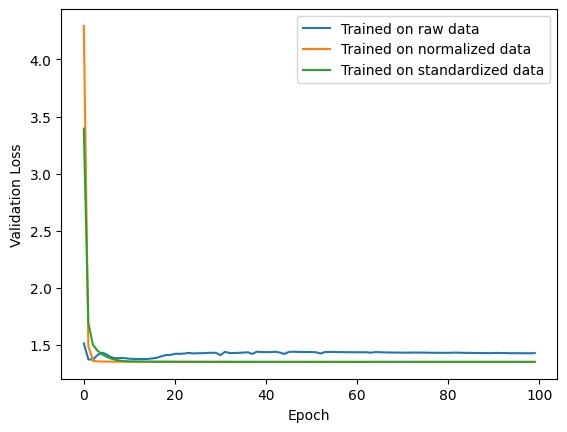

In [ ]:
plt.plot(raw_valid_losses, label="Trained on raw data")
plt.plot(norm_valid_losses, label="Trained on normalized data")
plt.plot(standard_valid_losses, label="Trained on standardized data")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.legend()
plt.show()

Loss converges quickest in model trained on normalized data, followed by model trained on standardized data.

In model trained on raw data, loss touches lowest around 10 epochs but then rises again and stays almost constant at an increased loss.

## Solution 8

In [ ]:
train_ds, valid_ds = random_split(
    CIFAR100(data_dir, download=True, train=True, transform=ToTensor()),
    [40_000, 10_000],
)
test_ds = CIFAR100(data_dir, download=True, train=False, transform=ToTensor())
train_loader = DataLoader(train_ds, batch_size=128)
valid_loader = DataLoader(valid_ds, batch_size=128)
test_loader = DataLoader(test_ds, batch_size=128)
len(train_ds), len(valid_ds), len(test_ds)

100%|██████████| 169M/169M [11:56<00:00, 236kB/s]  
/home/sohangchopra/DataScience/iit-madras-web-mtech-ai/.venv/lib64/python3.13/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


(40000, 10000, 10000)

In [ ]:
def conv_block(in_channels: int, out_channels: int):
    return [
        nn.Conv2d(in_channels, out_channels, kernel_size=(3, 3), padding="same"),
        nn.ReLU(),
        nn.Conv2d(out_channels, out_channels, kernel_size=(3, 3), padding="same"),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=(2, 2)),
    ]


def mk_model(dropout: float):
    return nn.Sequential(
        *conv_block(3, 32),
        *conv_block(32, 64),
        *conv_block(64, 128),
        # classification head
        nn.Flatten(),
        nn.Linear(2048, 512),
        nn.ReLU(),
        nn.Dropout(dropout),
        nn.Linear(512, 100),  # implicit Softmax added by Cross Entropy loss
    )


epochs = 15
loss_fn = nn.CrossEntropyLoss()

In [ ]:
def train(lr: float, dropout: float):
    model = mk_model(dropout).to(device)
    optimizer = optim.Adam(model.parameters(), lr)
    model.train()
    for _ in trange(epochs):
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            logits = model(images)
            loss = loss_fn(logits, labels)
            loss.backward()
            optimizer.step()
    return model


def validate(model, loader) -> tuple[float, float]:
    """Returns tuple (loss, accuracy)."""
    model.eval()
    with torch.no_grad():
        correct = 0
        loss = 0
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            logits = model(images)
            outputs = torch.argmax(logits, dim=1)
            loss += loss_fn(logits, labels).item()
            correct += (outputs == labels).sum().item()

        num_batches = len(loader)
        batch_size = 128
        return loss / batch_size, correct / (num_batches * batch_size)

In [ ]:
np.random.seed(42)
grid_search = list(product((0.0005, 0.0001, 0.005), (0.2, 0.4, 0.6)))
random_search = list(
    product(
        10 ** np.random.uniform(-4, -2, size=3),  # LR: log-uniform from 0.0001 to 0.01
        np.random.uniform(0.1, 0.6, size=3),  # Dropout
    )
)

In [ ]:
def hyperparams_search(hyperparams) -> pd.DataFrame:
    results = []
    for lr, dropout in hyperparams:
        print(f"{lr=:.5f}, {dropout=:.5f}: Training")
        model = train(lr, dropout)
        valid_loss, valid_accuracy = validate(model, valid_loader)
        print(f"{valid_loss=:.2f}, {valid_accuracy=:.2%}")
        results.append(
            {
                "lr": lr,
                "dropout": dropout,
                "val_loss": valid_loss,
                "val_accuracy": valid_accuracy,
            }
        )
    return pd.DataFrame(results)

In [ ]:
grid_results = hyperparams_search(grid_search)
grid_results.nlargest(3, "val_accuracy")

lr=0.00050, dropout=0.20000: Training


100%|██████████| 15/15 [01:34<00:00,  6.31s/it]


valid_loss=1.97, valid_accuracy=28.44%
lr=0.00050, dropout=0.40000: Training


100%|██████████| 15/15 [01:35<00:00,  6.34s/it]


valid_loss=1.79, valid_accuracy=31.94%
lr=0.00050, dropout=0.60000: Training


...

100%|██████████| 15/15 [01:34<00:00,  6.30s/it]


valid_loss=2.84, valid_accuracy=0.74%
lr=0.00500, dropout=0.60000: Training


100%|██████████| 15/15 [01:35<00:00,  6.34s/it]


valid_loss=2.84, valid_accuracy=0.74%


,lr,dropout,val_loss,val_accuracy
2,0.0005,0.6,1.570303,0.352749
1,0.0005,0.4,1.790468,0.319422
0,0.0005,0.2,1.967515,0.284415


In [ ]:
rand_results = hyperparams_search(random_search)
rand_results.nlargest(3, "val_accuracy")

lr=0.00056, dropout=0.39933: Training


100%|██████████| 15/15 [01:35<00:00,  6.38s/it]


valid_loss=1.77, valid_accuracy=31.54%
lr=0.00056, dropout=0.17801: Training


100%|██████████| 15/15 [01:36<00:00,  6.42s/it]


valid_loss=2.09, valid_accuracy=31.20%
lr=0.00056, dropout=0.17800: Training


...

100%|██████████| 15/15 [01:34<00:00,  6.30s/it]


valid_loss=2.84, valid_accuracy=0.74%
lr=0.00291, dropout=0.17800: Training


100%|██████████| 15/15 [01:34<00:00,  6.33s/it]


valid_loss=2.84, valid_accuracy=0.74%


,lr,dropout,val_loss,val_accuracy
0,0.000561,0.399329,1.771987,0.315368
1,0.000561,0.178009,2.094756,0.312006
2,0.000561,0.177997,1.907220,0.305281


In [ ]:
best_lr, best_dropout = 0.0005, 0.6
model = train(best_lr, best_dropout)
test_loss, test_accuracy = validate(model, test_loader)
print(f"{test_loss=:.2f}, {test_accuracy=:.2%}")

  0%|          | 0/15 [00:00<?, ?it/s]

100%|██████████| 15/15 [24:56<00:00, 99.74s/it]


test_loss=1.53, test_accuracy=37.57%


Here, Grid Search searched hyper-parameter space more effectively and found the best performing configuration `lr = 0.0005, dropout = 0.6` as its validation accuracy is 35.2% (after 15 epochs of training). On unseen test set, its accuracy is 37.57% .

## Solution 10

In [ ]:
# ToTensor() automatically transforms image pixels from (0,255) to (0,1)
batch_size = 512
train_ds = CIFAR10(data_dir, train=True, download=True, transform=ToTensor())
test_ds = CIFAR10(data_dir, train=False, download=True, transform=ToTensor())
train_loader = DataLoader(train_ds, batch_size=batch_size)
test_loader = DataLoader(test_ds, batch_size=batch_size)

/home/sohangchopra/DataScience/iit-madras-web-mtech-ai/.venv/lib64/python3.13/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


In [ ]:
model = nn.Sequential(
    # Conv2d(in_channels, out_channels, kernel_size)
    nn.Conv2d(
        3, 16, (3, 3), stride=1, padding=1
    ),  # seems to be given wrong in Q, input has 3 channels not 32
    nn.ReLU(),
    nn.MaxPool2d((2, 2), stride=2),
    nn.Conv2d(16, 32, (3, 3), stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d((2, 2), stride=2),
    nn.Conv2d(32, 64, (3, 3), stride=1, padding=1),
    nn.ReLU(),
    nn.Flatten(),
    nn.Linear(64 * 8 * 8, 128),
    nn.ReLU(),
    nn.Linear(128, 10),
    # implicit Softmax due to CrossEntropy loss
)
optimizer = optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.CrossEntropyLoss()

train_losses = []
model = model.to(device)
for epoch in range(50):
    curr_loss = 0
    for images, labels in tqdm(train_loader):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(images)
        loss = loss_fn(logits, labels)
        curr_loss += loss.item()
        loss.backward()
        optimizer.step()
    train_losses.append(curr_loss / batch_size)
    print(f"{epoch=}: Avg Train Loss over batches = {train_losses[epoch]}")

torch.save(
    model.state_dict(), "Q10_cnn.pth"
)  # torch saves as a zipped folder internally

  0%|          | 0/98 [00:00<?, ?it/s]

100%|██████████| 98/98 [00:29<00:00,  3.33it/s]


epoch=0: Avg Train Loss over batches = 0.3539617210626602


100%|██████████| 98/98 [00:30<00:00,  3.17it/s]


epoch=1: Avg Train Loss over batches = 0.28560977755114436


...

epoch=47: Avg Train Loss over batches = 0.05640855571255088


100%|██████████| 98/98 [00:40<00:00,  2.41it/s]


epoch=48: Avg Train Loss over batches = 0.05055173553409986


100%|██████████| 98/98 [00:44<00:00,  2.21it/s]

epoch=49: Avg Train Loss over batches = 0.04680983840080444


In [ ]:
with torch.no_grad():
    test_accuracy = sum(
        torch.sum(torch.argmax(model(images), dim=1) == labels)
        for images, labels in test_loader
    ) / len(test_ds)
    print("Test Accuracy:", test_accuracy)

Test Accuracy: tensor(0.6652)
